# Business Understanding

The business objective is to estimate an individual's medical insurance cost (`charges`) from demographic, lifestyle, and family information. A reliable estimate could support premium pricing, customer segmentation, risk assessment, and identifying policyholders who may need closer review. This is a supervised regression problem because `charges` is a continuous target.

The dataset describes 1,338 policyholders using age, sex, BMI, number of children, smoking status, region, and the recorded insurance charge. A useful analysis should focus on which factors are associated with higher costs, while remembering that association is not proof of causation and that pricing decisions should be checked for fairness and compliance.

# Data Understanding

- **Shape:** 1,338 rows and 7 columns.
- **Target:** `charges`, a continuous numeric variable ranging from about 1,121.87 to 63,770.43. Its mean (13,270.42) is higher than its median (9,382.03), suggesting a right-skewed distribution with some high-cost cases.
- **Numerical predictors:** `age`, `bmi`, and `children` are numeric. Age ranges from 18 to 64, BMI from 15.96 to 53.13, and children from 0 to 5.
- **Categorical predictors:** `sex` has 2 categories, `smoker` has 2 categories, and `region` has 4 categories. These will need encoding before most machine-learning models.
- **Data quality:** There are no missing values. There is 1 duplicate row, which should be investigated and generally removed before modeling if it represents an accidental duplicate rather than two genuine identical policies.
- **Initial patterns:** Mean charges are approximately 32,050 for smokers and 8,434 for non-smokers, so `smoker` appears to be the strongest business signal in this initial comparison. Numeric correlation with `charges` is strongest for `age` (about 0.30), followed by `bmi` (about 0.20); `children` has a weak correlation (about 0.07). Correlation alone does not capture nonlinear effects or interactions.

# Features

I would keep all seven fields in the first baseline model, with `charges` as the target and the other six fields as predictors. I would **not remove `sex` immediately**: its average charges differ somewhat, and it may interact with other variables, even though its median charges are very similar between groups. However, `sex` is a candidate for removal if cross-validated performance, fairness analysis, and the business rules show that it does not provide useful or acceptable information.

`region` and `children` may also have modest predictive value, but they should be tested rather than discarded based only on simple correlations. The most important feature to investigate is `smoker`, because it has a large apparent relationship with charges. Before deployment, check for leakage, fairness, legal constraints, and whether smoking status is legitimately available at prediction time. Finally, compare a full model with reduced models using cross-validation and appropriate regression metrics such as MAE and RMSE; remove a feature only when the simpler model performs similarly and is preferable for interpretability or policy reasons.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Data Types

In [5]:
print(df.dtypes)

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [6]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
cat_cols = ["region", "sex", "smoker", "children"]
df[cat_cols] = df[cat_cols].astype('category')

In [9]:
dtypes = df.dtypes
print(dtypes)
df.nunique()
pd.DataFrame({'dtypes': dtypes, 'unique': df.nunique()}).T

age            int64
sex         category
bmi          float64
children    category
smoker      category
region      category
charges      float64
dtype: object


,age,sex,bmi,children,smoker,region,charges
dtypes,int64,category,float64,category,category,category,float64
unique,47,2,548,6,2,4,1337


# Nulls

In [10]:
null = df.isnull().sum()
ratio = null / len(df) * 100
ratio

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

# Outliers

In [11]:
num_cols = df.select_dtypes("number").columns
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower_fence = q1 - 1.5 * IQR
    upper_fence = q3 + 1.5 * IQR

    print("=============================================================")
    print("before replacing outliers")
    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values
    print(f"Column: {col}, Lower Outliers: {len(lower_outliers)}, Upper Outliers: {len(upper_outliers)}")
    print("=============================================================")

    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values


    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)

   
    print("=============================================================")
    print("after replacing outliers")
    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values
    print(f"Column: {col}, Lower Outliers: {len(lower_outliers)}, Upper Outliers: {len(upper_outliers)}")
    print("=============================================================")

before replacing outliers
Column: age, Lower Outliers: 0, Upper Outliers: 0
after replacing outliers
Column: age, Lower Outliers: 0, Upper Outliers: 0
before replacing outliers
Column: bmi, Lower Outliers: 0, Upper Outliers: 9
after replacing outliers
Column: bmi, Lower Outliers: 0, Upper Outliers: 0
before replacing outliers
Column: charges, Lower Outliers: 0, Upper Outliers: 139
after replacing outliers
Column: charges, Lower Outliers: 0, Upper Outliers: 0


In [12]:
df.describe()

,age,bmi,charges
count,1338.000000,1338.000000,1338.000000
mean,39.207025,30.650034,12479.369251
std,14.049960,6.056926,10158.056096
min,18.000000,15.960000,1121.873900
25%,27.000000,26.296250,4740.287150
50%,39.000000,30.400000,9382.033000
75%,51.000000,34.693750,16639.912515
max,64.000000,47.290000,34489.350562


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols

Index(['age', 'bmi', 'charges'], dtype='str')

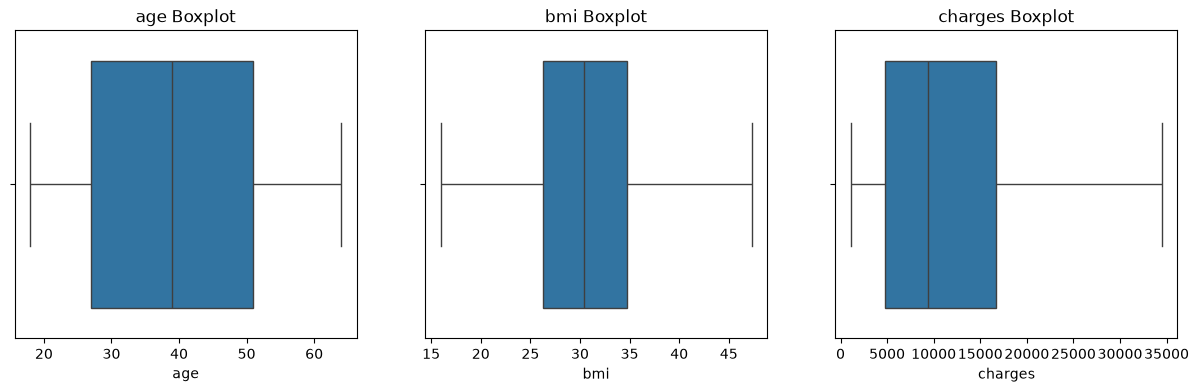

In [20]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(df[col]  , orient = 'h')
    plt.title(f"{col} Boxplot")

# Duplicated

In [21]:
df.duplicated().sum()

np.int64(1)

In [22]:
df.drop_duplicates(inplace=True)

# Visualizations

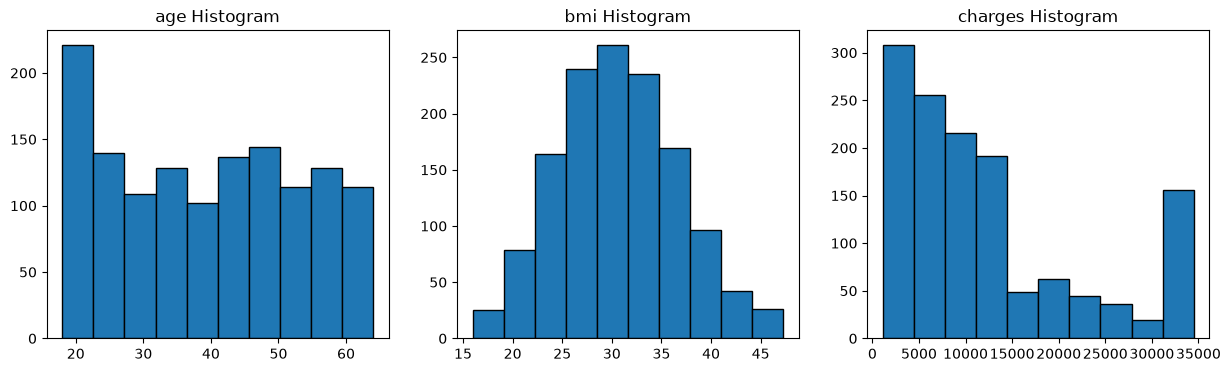

In [25]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    plt.hist(df[col] , edgecolor='black')
    plt.title(f"{col} Histogram")
  

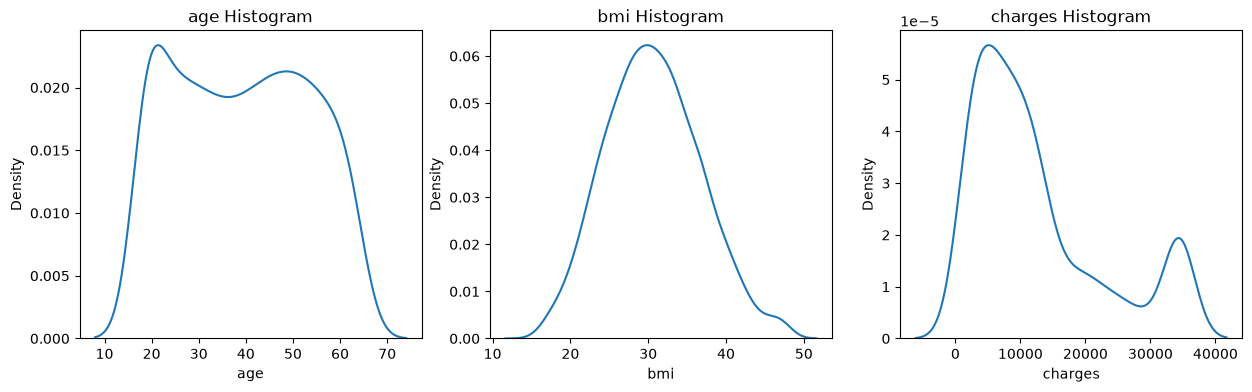

In [26]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(df[col])
    plt.title(f"{col} Histogram")

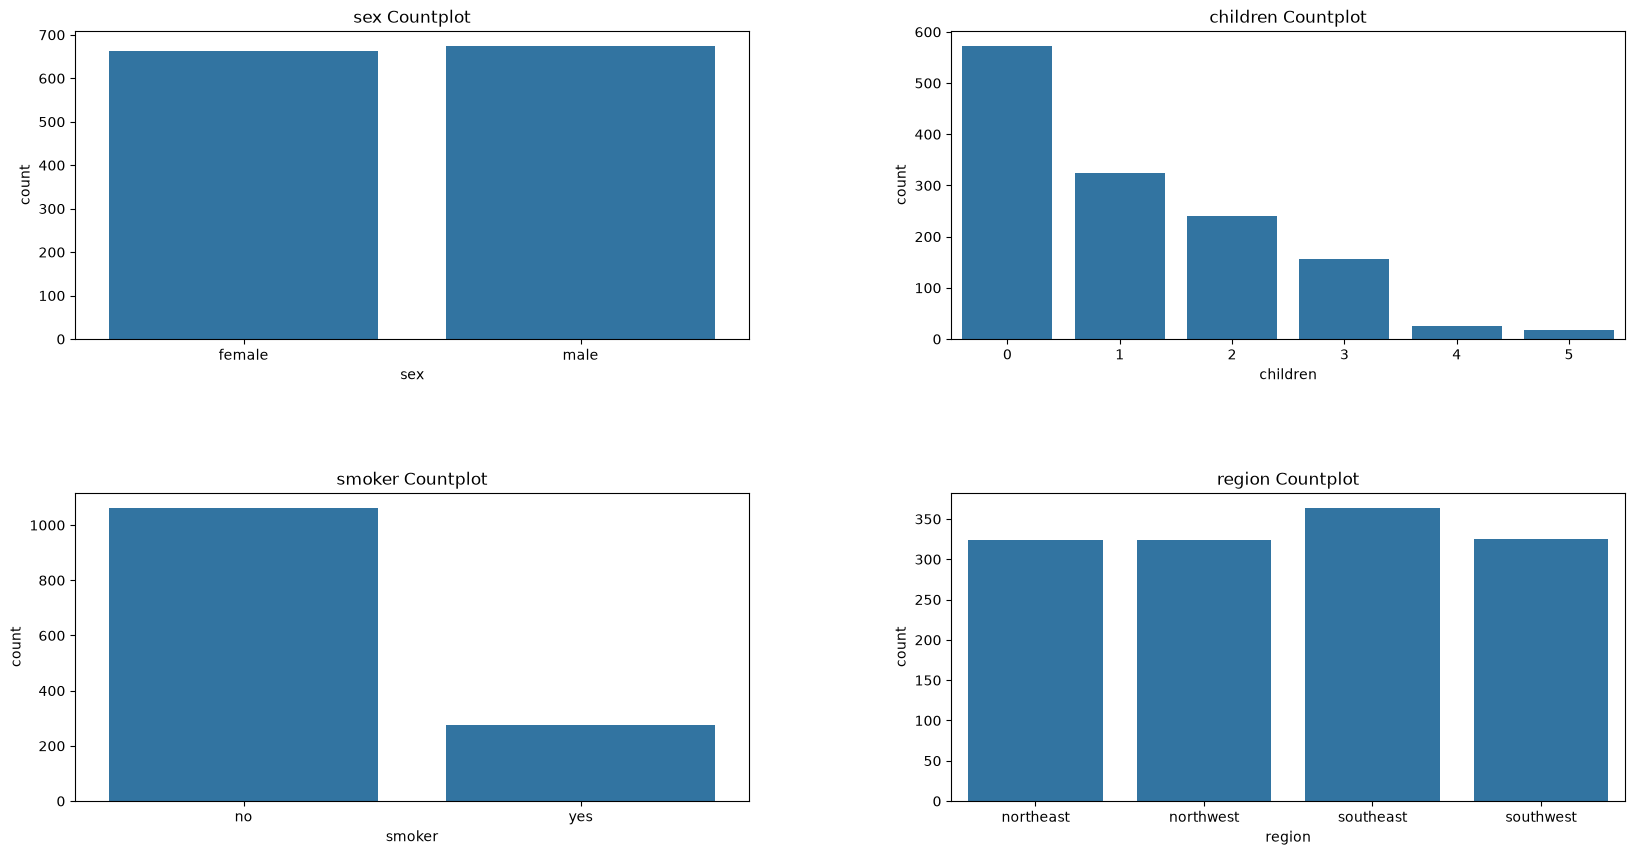

In [27]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(20, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Countplot")
plt.subplots_adjust(hspace=0.5, wspace=0.3)    

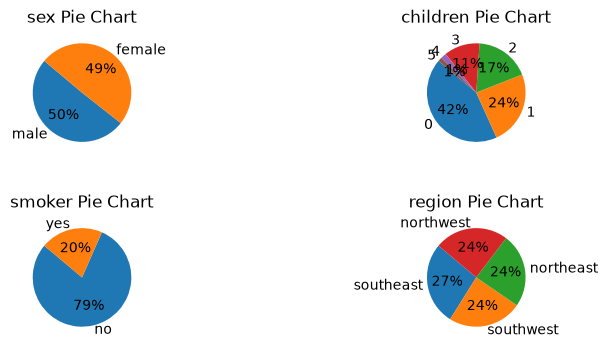

In [28]:
plt.figure(figsize=(9, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i + 1)
    unique = df[col].value_counts()
    counts = unique.values
    categories = unique.index
    plt.pie(counts, labels=categories, startangle=140, autopct='%1.1d%%')
    plt.title(f"{col} Pie Chart")
plt.subplots_adjust(hspace=0.5, wspace=0.3)    

Text(0, 0.5, 'charges')

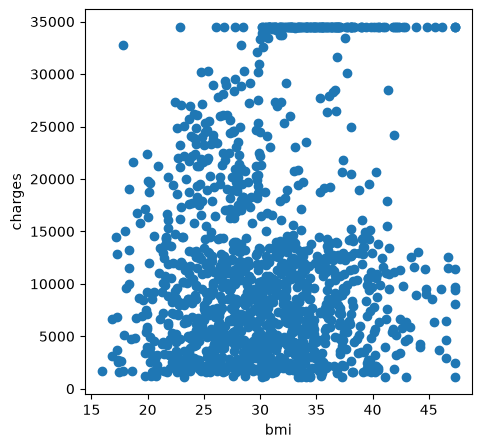

In [29]:
plt.figure(figsize=(5, 5))
plt.scatter(df['bmi'], df['charges'])
plt.xlabel('bmi')
plt.ylabel('charges')

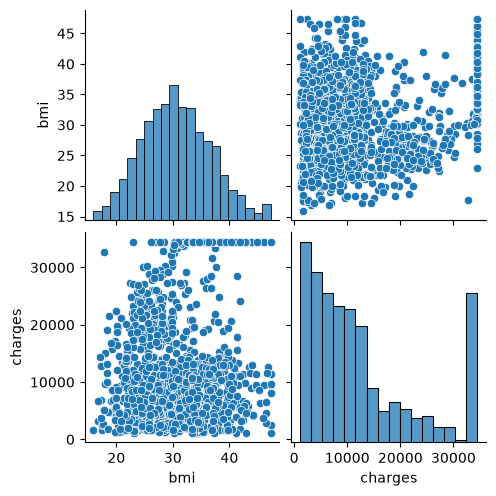

In [30]:
sns.pairplot(df[["bmi", "charges"]])

In [31]:
import plotly.express as px

In [33]:
fig = px.pie(df, names='region' , title='region Donut Chart', hole=0.6 , color_discrete_map = {0: 'blue', 1: 'red'})
fig.update_layout(
    title_text='region Donut Chart',
    annotations=[dict(text='Survived', x=0.5, y=0.5, font_size=20, showarrow=False)]
)
fig.show()

In [35]:
px.histogram(df , x="smoker" , title="Smoker Histogram" , color = "sex" , barmode = "group"  , text_auto=True)

In [37]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [43]:
fig = make_subplots(rows=2, cols=2, subplot_titles=cat_cols)
for i, col in enumerate(cat_cols):
    fig.add_trace(go.Histogram(x=df[col]), row=i // 2 + 1, col= i % 2 + 1)
fig.show()